In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import urllib.request
import os
import zipfile
import pretty_midi

from collections import Counter

In [82]:
urls = ['https://archive.org/download/doommusic/doommusic.zip', 'https://archive.org/download/doom2music/doom2music.zip']
zip_dir = '../data/'
raw_dir = '../data/raw/'
zip_paths = []

os.makedirs(raw_dir, exist_ok=True)

for url in urls:
    zip_path = zip_dir + url.split('/')[-1]
    zip_paths.append(zip_path)
    if not os.path.exists(zip_path):
        print(f'Downloading: {url}...', end='')
        urllib.request.urlretrieve(url, zip_path)
        print(' OK')
    else:
        print(f'File {url} exists, skipping')

for zip_path in zip_paths:
    print(f'Unzipping {zip_path}...', end='')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(raw_dir)
    print('OK')

midi_files = [f for f in os.listdir(raw_dir) if f.endswith('.mid')]

print(f"File count: {len(midi_files)}")

File https://archive.org/download/doommusic/doommusic.zip exists, skipping
File https://archive.org/download/doom2music/doom2music.zip exists, skipping
Unzipping ../data/doommusic.zip...OK
Unzipping ../data/doom2music.zip...OK
File count: 67


In [83]:
records = []
for file in midi_files:
    path = os.path.join(raw_dir, file)
    midi = pretty_midi.PrettyMIDI(path)

    n_instruments = len(midi.instruments)
    n_notes = sum(len(inst.notes) for inst in midi.instruments)
    duration = midi.get_end_time()
    tempos = midi.get_tempo_changes()[1]
    avg_tempo = np.mean(tempos)
    inst_names = [pretty_midi.program_to_instrument_name(inst.program) for inst in midi.instruments if not inst.is_drum]
    drum_track = any(inst.is_drum for inst in midi.instruments)

    records.append({
        'file': file,
        'duration_s': duration,
        'n_instruments': n_instruments,
        'n_notes': n_notes,
        'avg_tempo': avg_tempo,
        'has_drums': drum_track,
        'instruments': inst_names,
    })
records = pd.DataFrame(records)
display(records.head())

,file,duration_s,n_instruments,n_notes,avg_tempo,has_drums,instruments
0,d_adrian.mid,114.443353,5,929,95.000143,True,"[Electric Bass (finger), String Ensemble 1, Pi..."
1,d_ampie.mid,97.993939,5,2626,95.000143,True,"[Electric Guitar (muted), Slap Bass 2, Overdri..."
2,d_betwee.mid,153.991490,4,4217,95.000143,True,"[Electric Bass (finger), Electric Guitar (mute..."
3,d_bunny.mid,61.596596,12,742,95.000143,True,"[Pan Flute, Orchestral Harp, Piccolo, Bassoon,..."
4,d_count2.mid,228.879609,14,2494,95.000143,True,"[Pizzicato Strings, Pizzicato Strings, Pizzica..."


In [84]:
records = records.drop_duplicates(subset='n_notes')
print(f'Rows left: {len(records)}')

Rows left: 46


In [86]:
records = records[records['duration_s']>=60]
print(f'Rows left: {len(records)}')

Rows left: 43


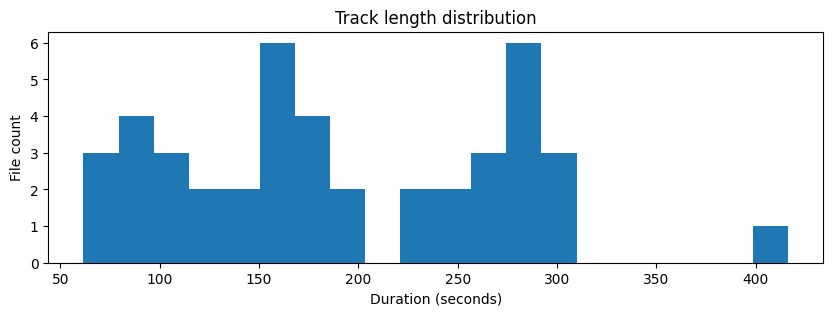

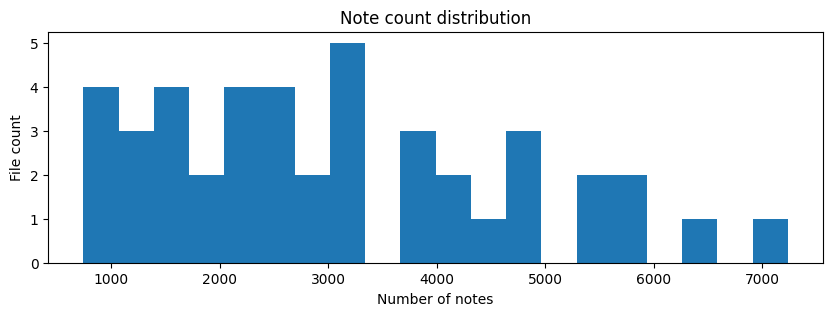

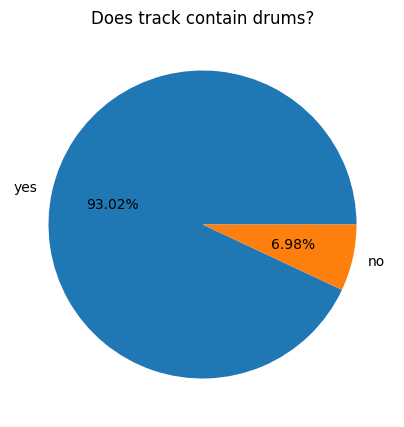

In [87]:
plt.figure(figsize=(10,3))
plt.hist(records['duration_s'], bins=20)
plt.xlabel('Duration (seconds)')
plt.ylabel('File count')
plt.title('Track length distribution')
plt.show()

plt.figure(figsize=(10,3))
plt.hist(records['n_notes'], bins=20)
plt.xlabel('Number of notes')
plt.ylabel('File count')
plt.title('Note count distribution')
plt.show()

plt.figure(figsize=(5,5))
plt.pie(records['has_drums'].value_counts(), labels=['yes', 'no'], autopct='%1.2f%%');
plt.title('Does track contain drums?');